In [ ]:
import yfinance as yf
import pandas as pd

# Define the stock ticker and the time window you want to analyze
ticker = "RELIANCE.NS" 
start_date = "2021-01-01"
end_date = "2026-01-01" # Fetches data up to this point

# Fetch the historical data
print(f"Fetching data for {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date)

# Preview the data
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Save it to a CSV file so you have a physical copy for your task deliverables
df.to_csv("stock_market_data.csv")
print("\nDataset successfully downloaded and saved as 'stock_market_data.csv'!")

In [6]:
import pandas as pd

df = pd.read_csv("./stock_market_data.csv")

print(df.head())
print(df.columns)

       Date       Close        High         Low        Open    Volume
0  1/1/2021  897.047058  901.334799  894.564644  897.272694  10015175
1  1/4/2021  898.559082  902.192359  888.245845  900.477286  24513534
2  1/5/2021  887.388306  895.286819  882.829682  888.697173  24123091
3  1/6/2021  863.986084  887.343111  859.878852  887.297983  46401468
4  1/7/2021  862.586914  877.864919  859.878864  866.806964  32325918
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [7]:
import pandas as pd

df = pd.read_csv("./stock_market_data.csv")

print(df.head())

       Date       Close        High         Low        Open    Volume
0  1/1/2021  897.047058  901.334799  894.564644  897.272694  10015175
1  1/4/2021  898.559082  902.192359  888.245845  900.477286  24513534
2  1/5/2021  887.388306  895.286819  882.829682  888.697173  24123091
3  1/6/2021  863.986084  887.343111  859.878852  887.297983  46401468
4  1/7/2021  862.586914  877.864919  859.878864  866.806964  32325918


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())

                 Close        High         Low        Open    Volume
Date                                                                
2021-01-01  897.047058  901.334799  894.564644  897.272694  10015175
2021-01-04  898.559082  902.192359  888.245845  900.477286  24513534
2021-01-05  887.388306  895.286819  882.829682  888.697173  24123091
2021-01-06  863.986084  887.343111  859.878852  887.297983  46401468
2021-01-07  862.586914  877.864919  859.878864  866.806964  32325918


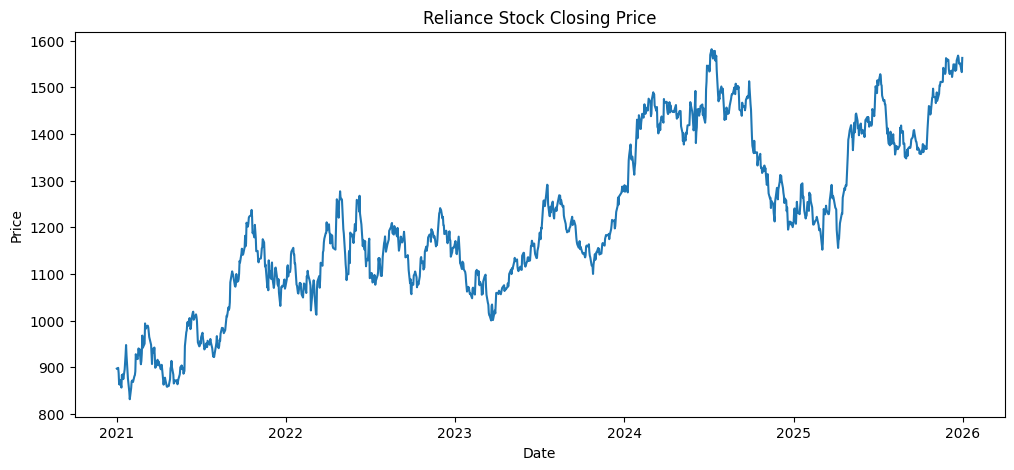

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Reliance Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

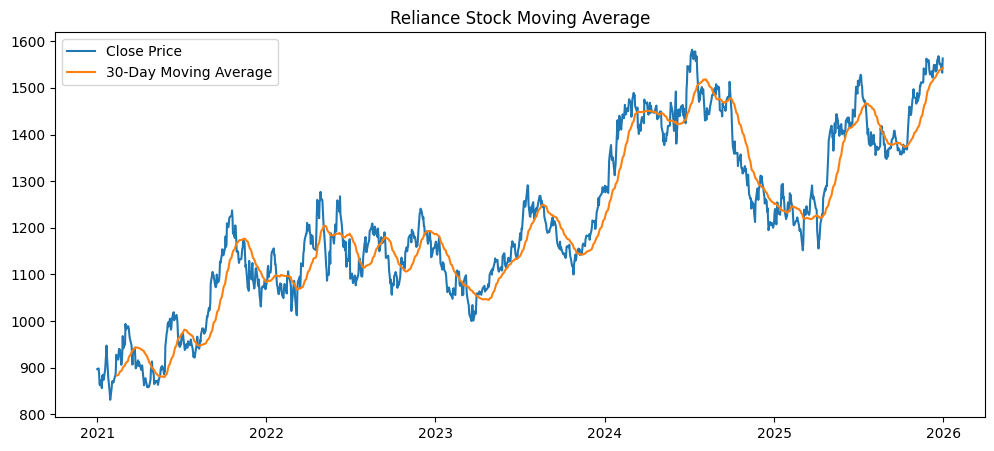

In [10]:
df['MA30'] = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA30'], label='30-Day Moving Average')
plt.legend()
plt.title("Reliance Stock Moving Average")
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'].dropna())

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -1.5931613739266497
P-value: 0.4870278696222045


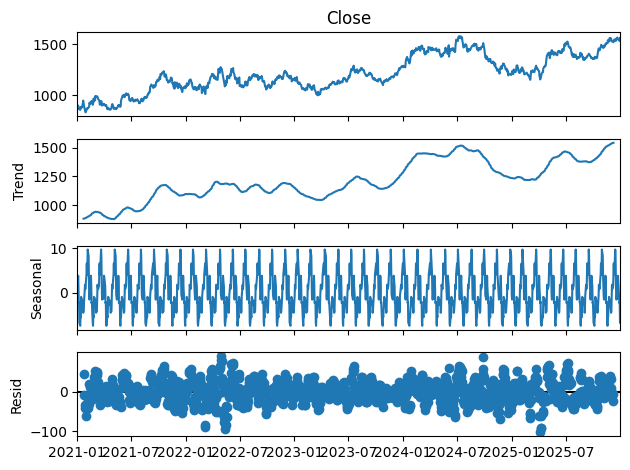

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['Close'],
    model='additive',
    period=30
)

decomposition.plot()
plt.show()

In [13]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Close'], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print(forecast)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


1236    1564.663311
1237    1565.330119
1238    1563.968897
1239    1564.447011
1240    1563.265618
1241    1563.295860
1242    1563.207230
1243    1563.334470
1244    1563.300796
1245    1563.352491
1246    1563.342621
1247    1563.350197
1248    1563.341842
1249    1563.344341
1250    1563.341721
1251    1563.342697
1252    1563.342132
1253    1563.342643
1254    1563.342455
1255    1563.342605
1256    1563.342530
1257    1563.342570
1258    1563.342539
1259    1563.342553
1260    1563.342543
1261    1563.342549
1262    1563.342546
1263    1563.342548
1264    1563.342547
1265    1563.342547
Name: predicted_mean, dtype: float64


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
